# Past rates EDA, ETL and Visualization
#### Dataset: `../data/past_rates.parquet`

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setting up libraries configurations

# Pandas
pd.set_option('display.max_rows', 100)
pd.set_option('display.date_yearfirst', True)

# Matplotlib and seaborn defaults for readability
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

In [4]:
RATES_DATASET = "../data/past_rates.parquet"
EXACT_COLUMNS = [
    'listing_id', 'date', 'vacant_days', 'reserved_days', 'occupancy', 'revenue', 'rate_avg',
    'booked_rate_avg', 'booking_lead_time_avg', 'length_of_stay_avg', 'min_nights_avg',
    'native_booked_rate_avg', 'native_rate_avg', 'native_revenue', 'country', 'state', 'city'
 ]

In [5]:
# df_rates = pd.read_parquet(RATES_DATASET)
# df_rates.head()
df_pqt = pd.read_parquet(RATES_DATASET, engine='pyarrow')
df_pqt.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city
0,715948003276412382,2025-02-01,7,21,0.750,860.0,40.6,41.0,7.0,4.0,2.0,1469.0,1455.0,30821.0,Turkey,Istanbul,Kadıköy
1,715948003276412382,2025-03-01,4,27,0.871,1100.0,40.8,40.7,34.0,4.0,3.0,1482.0,1485.0,40044.0,Turkey,Istanbul,Kadıköy
2,715948003276412382,2025-04-01,8,22,0.733,886.0,40.5,40.3,15.0,4.0,3.0,1530.0,1538.0,33637.0,Turkey,Istanbul,Kadıköy
3,715948003276412382,2025-05-01,3,28,0.903,1117.0,40.6,39.9,23.0,10.0,3.0,1539.0,1566.0,43088.0,Turkey,Istanbul,Kadıköy
4,715948003276412382,2025-06-01,23,7,0.233,320.0,51.0,45.7,13.0,4.0,3.0,1793.0,2001.0,12557.0,Turkey,Istanbul,Kadıköy


In [6]:
# Analysing columns
print(list(df_pqt.columns) == EXACT_COLUMNS)

True


In [7]:
# %%
# Checking Non-Nulls, Nulls and Columns types
non_null_count_rates = df_pqt.notnull().sum().values
nulls = df_pqt.isna().sum()
types = df_pqt.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_rates,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                        Non-Null Count  Null Count   Dtypes
listing_id                     1115174           0    int64
date                           1115174           0   object
vacant_days                    1115174           0    int32
reserved_days                  1115174           0    int32
occupancy                      1115174           0  float64
revenue                        1115174           0  float64
rate_avg                       1115174           0  float64
booked_rate_avg                 717806      397368  float64
booking_lead_time_avg           675943      439231  float64
length_of_stay_avg              675943      439231  float64
min_nights_avg                 1089672       25502  float64
native_booked_rate_avg          717806      397368  float64
native_rate_avg                1115174           0  float64
native_revenue                 1115174           0  float64
country                        1115174           0      str
state                          1115174  

In [8]:
# Defining correct column dtypes

str_cols = ['city', 'state', 'country']

# This temporary dataset does not include boolean flags such as superhost
bool_cols = []

float_cols = [
    'occupancy', 'revenue', 'rate_avg', 'booked_rate_avg',
    'booking_lead_time_avg', 'length_of_stay_avg', 'min_nights_avg',
    'native_revenue', 'native_rate_avg', 'native_booked_rate_avg'
 ]

int_cols = [
    'vacant_days', 'reserved_days'
 ]

In [9]:
# Remove columns
cols_to_remove = ['state']

df_fixing = df_pqt.drop(cols_to_remove, axis=1)

print(len(df_fixing))

1115174


In [10]:
# %% [markdown]
# ### Convert and clean

# %%
# 1. Decode date column (robust handling for bytes)
if 'date' in df_fixing.columns:
    # Convert to string first to handle byte values
    df_fixing['date'] = df_fixing['date'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
    # Then safely convert to datetime
    df_fixing['date'] = pd.to_datetime(df_fixing['date'], errors='coerce')

# 2. Define numeric columns
new_numeric_cols = float_cols + int_cols

# 3. Convert only existing columns to avoid KeyError
existing_numeric_cols = [c for c in new_numeric_cols if c in df_fixing.columns]
missing_numeric_cols = [c for c in new_numeric_cols if c not in df_fixing.columns]

if missing_numeric_cols:
    print(f"Numeric columns not found (skipped): {missing_numeric_cols}")

df_fixing[existing_numeric_cols] = df_fixing[existing_numeric_cols].apply(pd.to_numeric, errors='coerce')

# 4. Drop rows where date conversion failed
df_fixing = df_fixing.dropna(subset=['date'])

print(f"Dataset ready for profitability analysis: {len(df_fixing)} rows")

Dataset ready for profitability analysis: 1115174 rows


In [11]:
# %%
# Keep rows with coherent and valid business values
df_fixing = df_fixing[
    # 1. Revenue and rates must be non-negative/positive
    (df_fixing['native_revenue'] >= 0) &
    (df_fixing['native_rate_avg'] > 0) &

    # 2. Day counts must be coherent
    (df_fixing['reserved_days'] >= 0) &
    (df_fixing['vacant_days'] >= 0) &
    ((df_fixing['reserved_days'] + df_fixing['vacant_days']) <= 31)
 ]

print(f"Rows after consistency filters: {len(df_fixing)}")

Rows after consistency filters: 1115174


In [12]:
# ### Adding columns (time and performance metrics)

# %%
# 1. Occupancy rate = reserved days / total days
df_fixing['occupancy_rate'] = (df_fixing['reserved_days'] / (df_fixing['reserved_days'] + df_fixing['vacant_days'])).fillna(0)

# 2. Month for yearly profitability analysis
df_fixing['month'] = df_fixing['date'].dt.month

print("New columns 'occupancy_rate' and 'month' were created successfully.")

New columns 'occupancy_rate' and 'month' were created successfully.


In [13]:
# #### 1. Data quality overview

# %%
# Generamos el reporte de salud de los datos limpios
non_null_count_rates = df_fixing.notnull().sum().values
nulls = df_fixing.isna().sum()
types = df_fixing.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_rates,
    'Null Count': nulls,
    'Dtypes': types
}, index=df_fixing.columns)
print(info_df)

                        Non-Null Count  Null Count         Dtypes
listing_id                     1115174           0          int64
date                           1115174           0  datetime64[s]
vacant_days                    1115174           0          int32
reserved_days                  1115174           0          int32
occupancy                      1115174           0        float64
revenue                        1115174           0        float64
rate_avg                       1115174           0        float64
booked_rate_avg                 717806      397368        float64
booking_lead_time_avg           675943      439231        float64
length_of_stay_avg              675943      439231        float64
min_nights_avg                 1089672       25502        float64
native_booked_rate_avg          717806      397368        float64
native_rate_avg                1115174           0        float64
native_revenue                 1115174           0        float64
country   

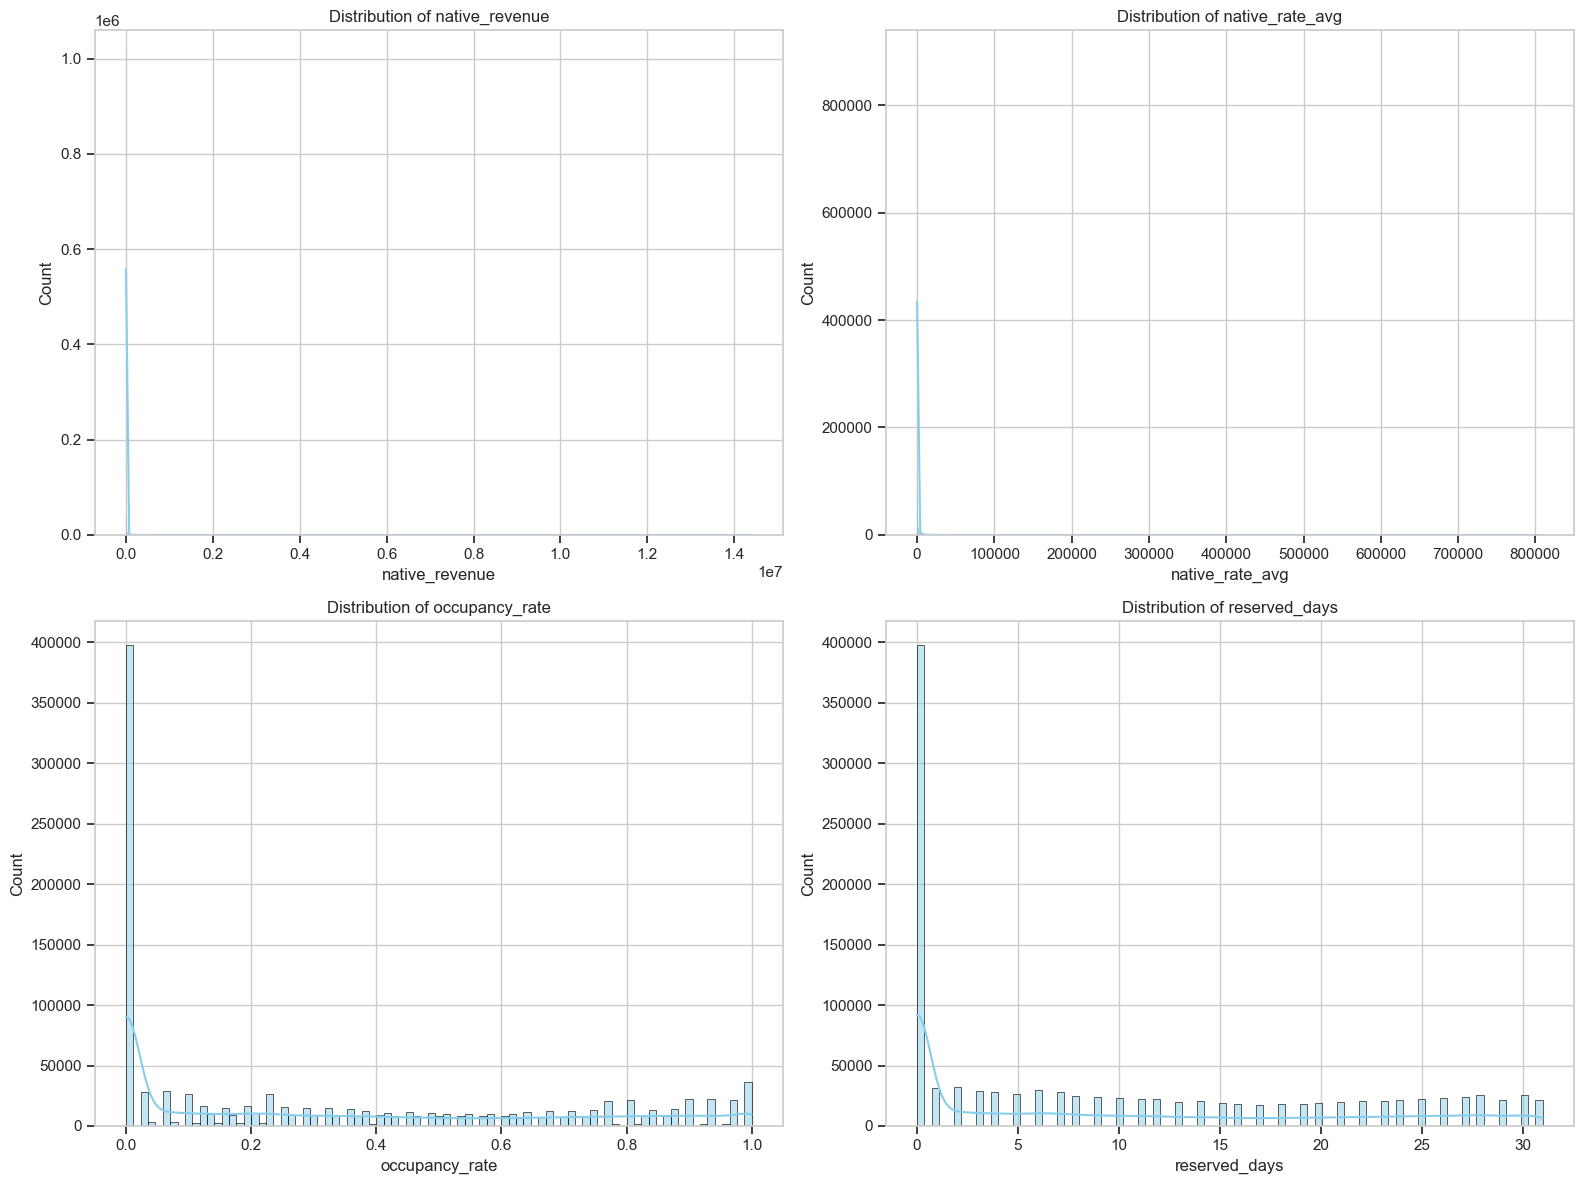

In [14]:
# #### 2. Distributions of key numeric columns

# %%
# Visualize how profitability and occupancy are distributed
key_numeric_cols = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'reserved_days']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric_cols):
    sns.histplot(df_fixing[col].dropna(), kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()

revpar column was missing and has been created in this cell.


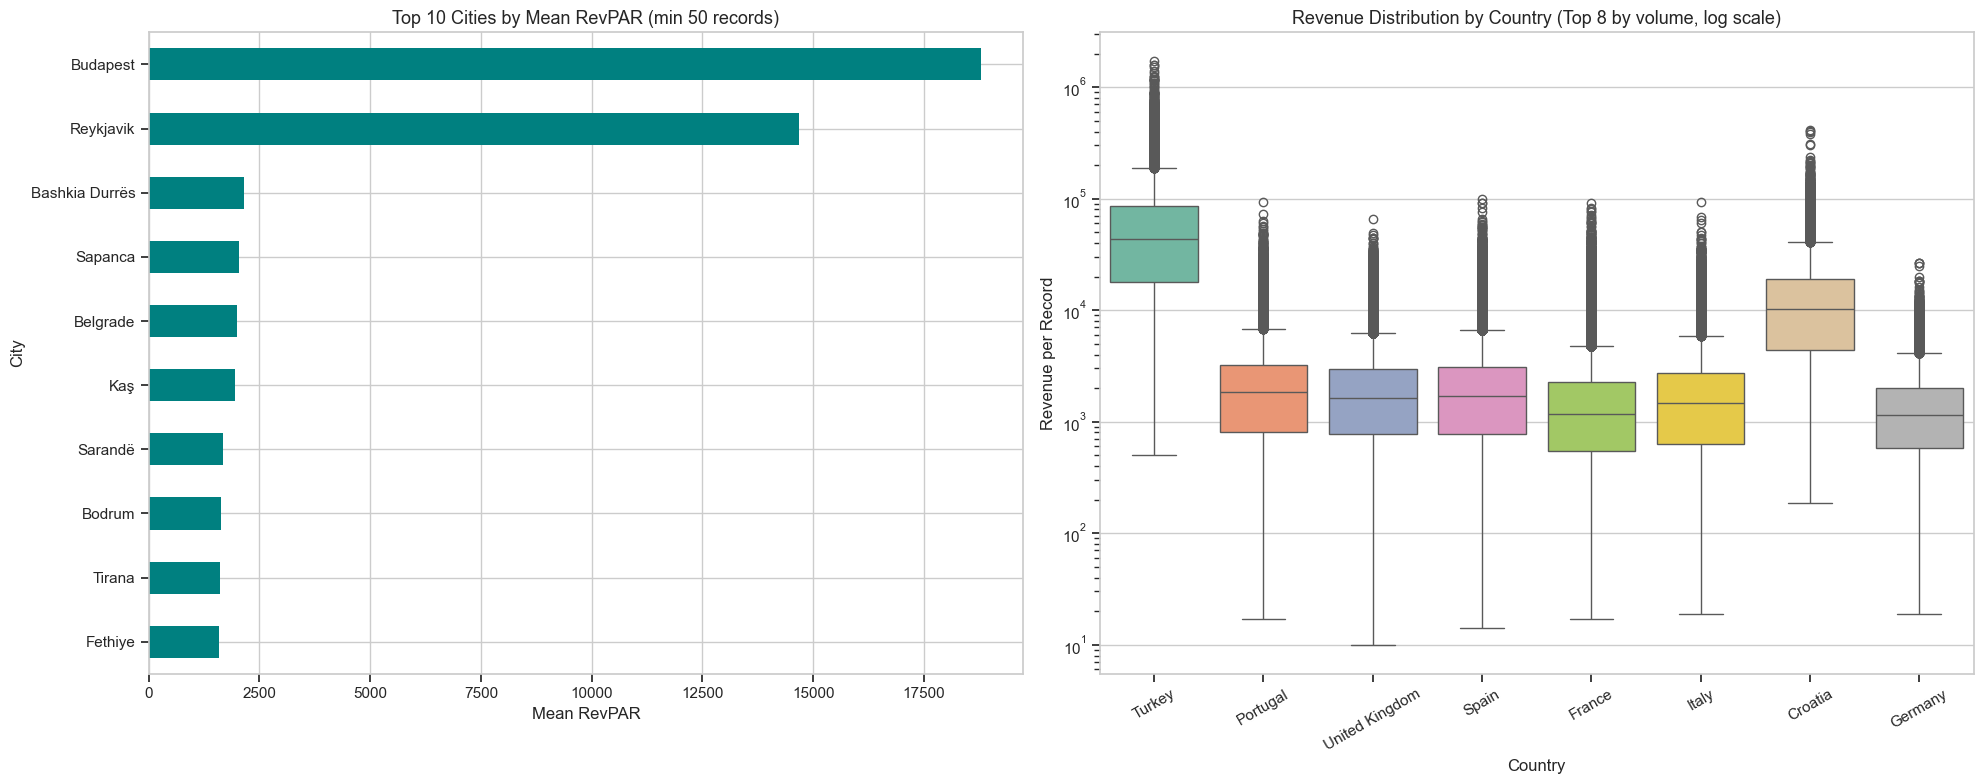

In [15]:
# %% [markdown]
# #### 3. Geographic profitability analysis

# %%
# Ensure revpar exists even if cells are run out of order
if 'revpar' not in df_fixing.columns:
    df_fixing['revpar'] = df_fixing['native_revenue'] / (df_fixing['reserved_days'] + df_fixing['vacant_days'])
    print('revpar column was missing and has been created in this cell.')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# A. Top cities by mean RevPAR (minimum sample size to avoid low-volume bias)
city_stats = (
    df_fixing.groupby('city')
    .agg(
        mean_revpar=('revpar', 'mean'),
        records=('city', 'size')
    )
    .query('records >= 50')
    .sort_values('mean_revpar', ascending=False)
    .head(10)
 )

city_stats.sort_values('mean_revpar').plot(
    kind='barh', y='mean_revpar', legend=False, ax=axes[0], color='teal'
 )
axes[0].set_title('Top 10 Cities by Mean RevPAR (min 50 records)', fontsize=13)
axes[0].set_xlabel('Mean RevPAR')
axes[0].set_ylabel('City')

# B. Country-level revenue distribution for highest-volume countries
top_countries = df_fixing['country'].value_counts().head(8).index
df_country_plot = df_fixing[df_fixing['country'].isin(top_countries) & (df_fixing['native_revenue'] > 0)]

sns.boxplot(
    data=df_country_plot, x='country', y='native_revenue', hue='country',
    ax=axes[1], palette='Set2', legend=False
 )
axes[1].set_yscale('log')
axes[1].set_title('Revenue Distribution by Country (Top 8 by volume, log scale)', fontsize=13)
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Revenue per Record')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [16]:
# %% [markdown]
# ### Final Verification
# #### Checking results after ETL process

# %%
non_null_count_final = df_fixing.notnull().sum().values
nulls_final = df_fixing.isna().sum()
types_final = df_fixing.dtypes.values

info_df_final = pd.DataFrame({
    'Non-Null Count': non_null_count_final,
    'Null Count': nulls_final,
    'Dtypes': types_final
}, index=df_fixing.columns)

print(info_df_final)

                        Non-Null Count  Null Count         Dtypes
listing_id                     1115174           0          int64
date                           1115174           0  datetime64[s]
vacant_days                    1115174           0          int32
reserved_days                  1115174           0          int32
occupancy                      1115174           0        float64
revenue                        1115174           0        float64
rate_avg                       1115174           0        float64
booked_rate_avg                 717806      397368        float64
booking_lead_time_avg           675943      439231        float64
length_of_stay_avg              675943      439231        float64
min_nights_avg                 1089672       25502        float64
native_booked_rate_avg          717806      397368        float64
native_rate_avg                1115174           0        float64
native_revenue                 1115174           0        float64
country   

In [17]:
# %% [markdown]
# ### Adding business metric: RevPAR
# #### (Revenue Per Available Room)

# %%
# RevPAR = total revenue / (reserved days + vacant days)
df_fixing['revpar'] = df_fixing['native_revenue'] / (df_fixing['reserved_days'] + df_fixing['vacant_days'])

print(df_fixing[['revpar', 'native_revenue']].describe())

             revpar  native_revenue
count  1.115174e+06    1.115174e+06
mean   2.568930e+02    7.836094e+03
std    2.453233e+03    7.489021e+04
min    0.000000e+00    0.000000e+00
25%    0.000000e+00    0.000000e+00
50%    2.273333e+01    6.900000e+02
75%    7.877419e+01    2.400000e+03
max    4.646027e+05    1.440268e+07


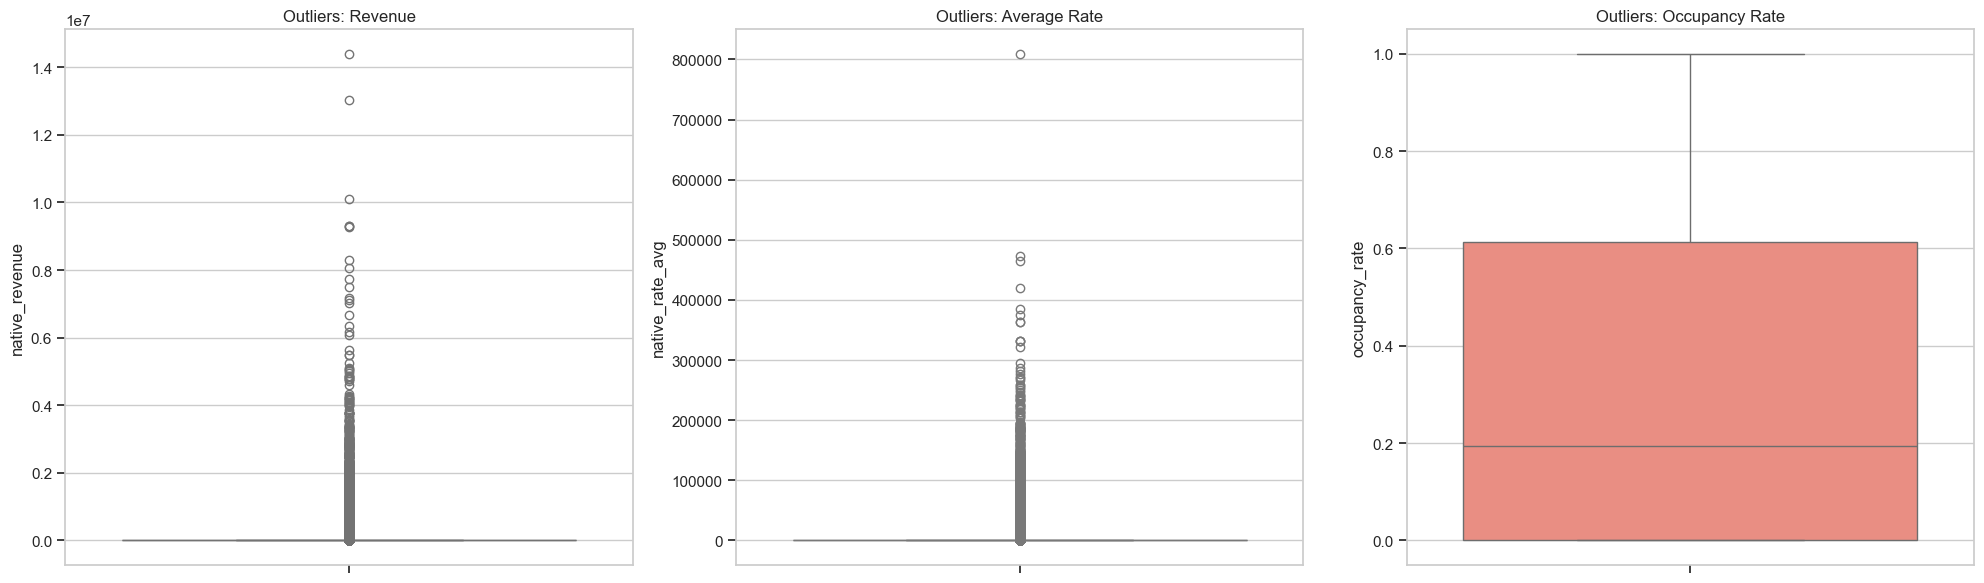

In [18]:
# %% [markdown]
# #### 4. Outliers analysis
# %%
# Visualize the spread of core profitability metrics
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(y=df_fixing['native_revenue'], ax=axes[0], color='lightgreen')
axes[0].set_title('Outliers: Revenue')

sns.boxplot(y=df_fixing['native_rate_avg'], ax=axes[1], color='lightblue')
axes[1].set_title('Outliers: Average Rate')

sns.boxplot(y=df_fixing['occupancy_rate'], ax=axes[2], color='salmon')
axes[2].set_title('Outliers: Occupancy Rate')

plt.tight_layout()
plt.show()

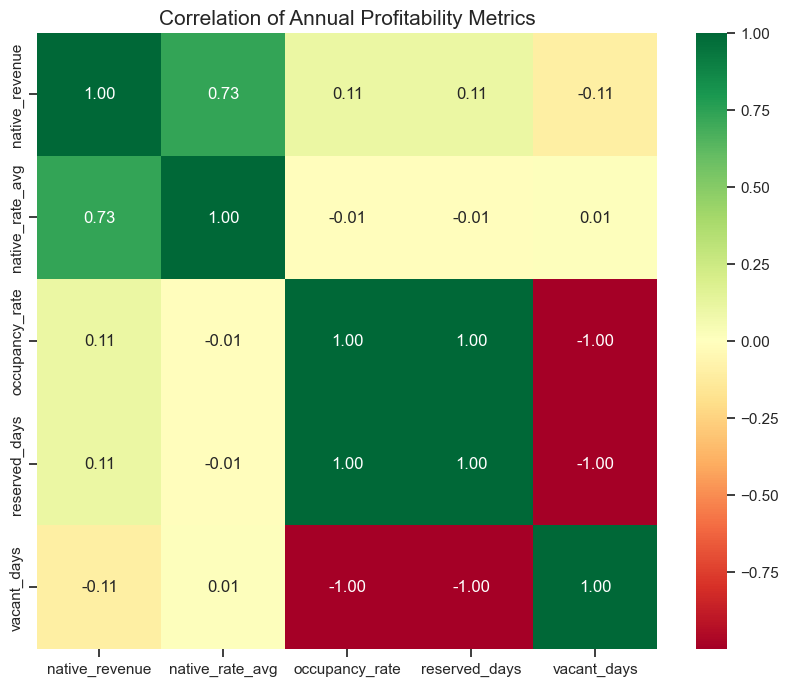

In [19]:
# %% [markdown]
# #### 6. Correlation heatmap
# %%
# Select numeric columns relevant to profitability
corr_cols = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'reserved_days', 'vacant_days']

plt.figure(figsize=(10, 8))
sns.heatmap(df_fixing[corr_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation of Annual Profitability Metrics', fontsize=15)
plt.show()

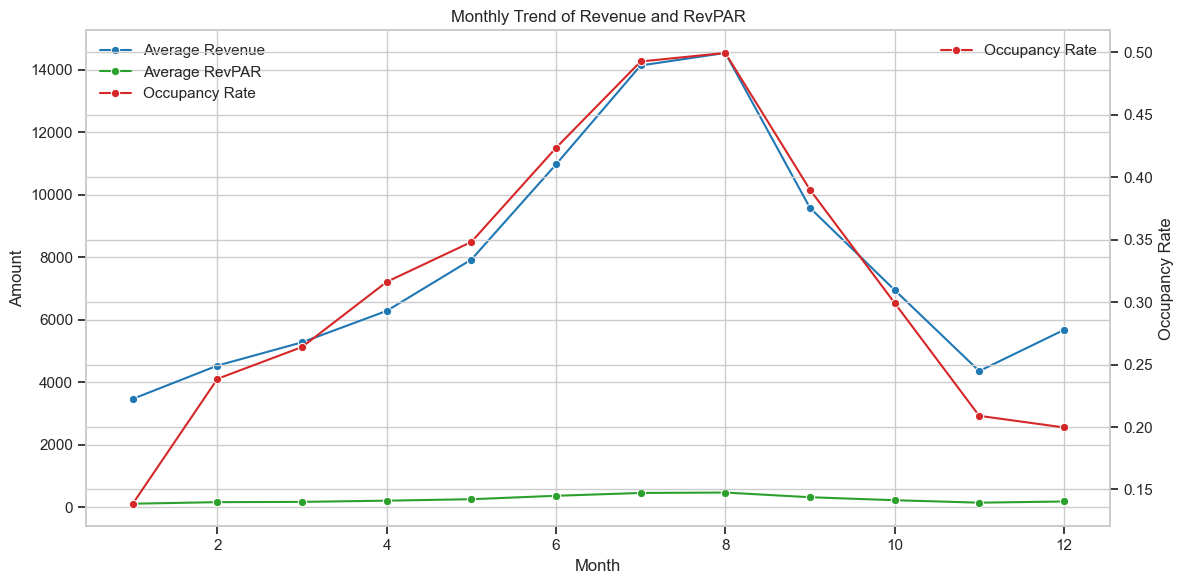

In [20]:
# %% [markdown]
# #### 7. Monthly trend of profitability metrics
# %%
monthly_trend = (
    df_fixing.groupby('month')[['native_revenue', 'revpar', 'occupancy_rate']]
    .mean()
    .sort_index()
 )

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='native_revenue', marker='o', ax=ax1, color='tab:blue', label='Average Revenue')
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='revpar', marker='o', ax=ax1, color='tab:green', label='Average RevPAR')
ax1.set_xlabel('Month')
ax1.set_ylabel('Amount')
ax1.set_title('Monthly Trend of Revenue and RevPAR')

ax2 = ax1.twinx()
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='occupancy_rate', marker='o', ax=ax2, color='tab:red', label='Occupancy Rate')
ax2.set_ylabel('Occupancy Rate')

# Merge legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()

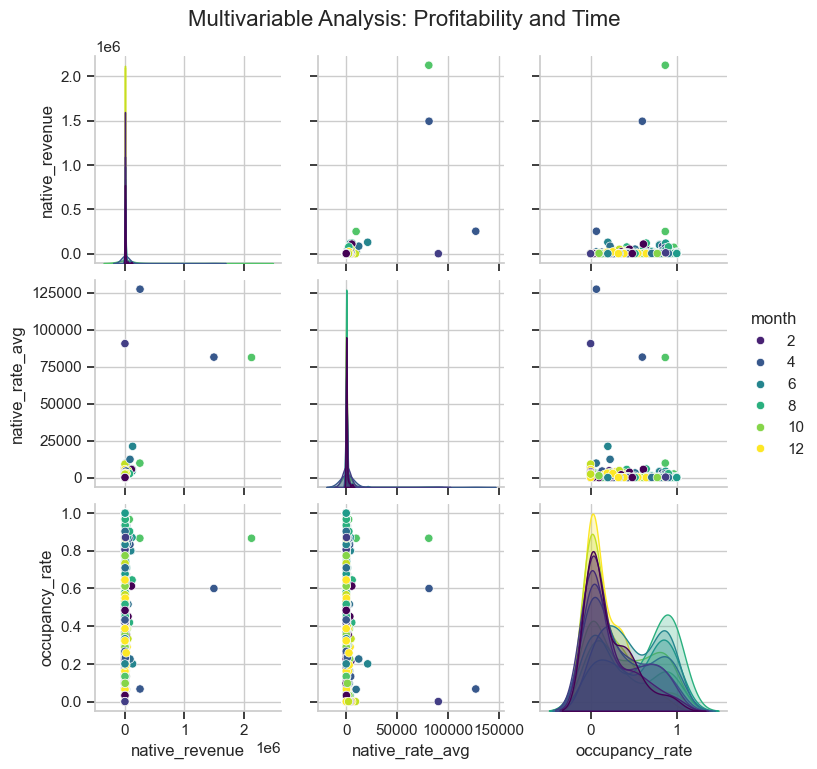

In [21]:
# %% [markdown]
# #### 8. Scatter matrix (pairplot)
# %%
# Select key metrics for multivariate analysis
cols_to_plot = ['native_revenue', 'native_rate_avg', 'occupancy_rate', 'month']

# Sample data to keep plotting fast
df_sample = df_fixing[cols_to_plot].sample(n=min(1000, len(df_fixing)))

g = sns.pairplot(df_sample, hue='month', palette='viridis', diag_kind='kde', height=2.5)
g.fig.suptitle('Multivariable Analysis: Profitability and Time', y=1.02, fontsize=16)

plt.show()

In [22]:
# %% [markdown]
# #### 9. Export cleaned parquet
# %%
df_fixing.to_parquet(path='../data/clean_past_rates.parquet', engine='pyarrow')
print(f'Process completed successfully. Final records: {len(df_fixing)}')

Process completed successfully. Final records: 1115174


In [23]:
# %% [markdown]
# #### 10. Consistency checks for profitability variables

# %%
total_days = df_fixing['reserved_days'] + df_fixing['vacant_days']
zero_total_days = int((total_days == 0).sum())
invalid_months = int((~df_fixing['month'].between(1, 12)).sum())

occ_diff = (df_fixing['occupancy_rate'] - (df_fixing['reserved_days'] / total_days).fillna(0)).abs()
revpar_diff = (df_fixing['revpar'] - (df_fixing['native_revenue'] / total_days)).abs()

print('--- Consistency checks ---')
print(f'Records: {len(df_fixing):,}')
print(f'Records with reserved+vacant = 0: {zero_total_days:,}')
print(f'Month values outside 1..12: {invalid_months:,}')
print(f'Max difference in reconstructed occupancy_rate: {occ_diff.max():.10f}')
print(f'Max difference in reconstructed revpar: {revpar_diff.max():.10f}')

if 'occupancy' in df_fixing.columns:
    base_occ = pd.to_numeric(df_fixing['occupancy'], errors='coerce')
    valid = base_occ.notna() & df_fixing['occupancy_rate'].notna()
    if valid.any():
        mae = (df_fixing.loc[valid, 'occupancy_rate'] - base_occ.loc[valid]).abs().mean()
        print(f'Mean absolute error vs original occupancy: {mae:.6f}')
    else:
        print('No valid overlap to compare against original occupancy.')

print('\n--- Profitability comparison checks ---')
city_n = int((city_stats['records'] >= 50).sum()) if 'city_stats' in globals() else 0
print(f'Cities in ranking with n>=50: {city_n}')
print(f'Countries used in boxplot: {len(top_countries) if "top_countries" in globals() else 0}')

--- Consistency checks ---
Records: 1,115,174
Records with reserved+vacant = 0: 0
Month values outside 1..12: 0
Max difference in reconstructed occupancy_rate: 0.0000000000
Max difference in reconstructed revpar: 0.0000000000
Mean absolute error vs original occupancy: 0.000152

--- Profitability comparison checks ---
Cities in ranking with n>=50: 10
Countries used in boxplot: 8


### 11. Executive conclusions

- The ETL pipeline is consistent for profitability analysis: cleaned types, valid dates, and coherent day-count filters.
- Geographic comparisons are more robust by using mean RevPAR and a minimum number of records per city.
- Country-level comparisons focus on the highest-volume countries to reduce visual noise and small-sample bias.
- Core business metrics (revenue, RevPAR, and occupancy) provide a clear monthly trend view.
- Consistency checks confirm that occupancy and RevPAR formulas are correctly implemented.